<h1>DNN Model</h1>

Using data in advanced preprocssing

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import numpy as np
import os
from PIL import Image
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import tensorflow as tf
from tensorflow.keras import layers, models



In [3]:
import pandas as pd
import os

def clean_metadata(meta_path, img_dir):
    df = pd.read_csv(meta_path)
    valid_rows = []
    for idx, row in df.iterrows():
        base_name = row['photo_id']
        found = False
        for ext in ['.jpg', '.png', '.jpeg']:
            img_path = os.path.join(img_dir, base_name + ext).replace("\\", "/")
            if os.path.exists(img_path):
                found = True
                break
        if found:
            valid_rows.append(row)
        else:
            print(f"Will remove missing: {img_dir}/{base_name}")
    clean_df = pd.DataFrame(valid_rows)
    clean_csv_path = meta_path.replace('.csv', '_clean.csv')
    clean_df.to_csv(clean_csv_path, index=False)
    print(f"Saved cleaned CSV to {clean_csv_path} (now only valid images)")
    return clean_df

# Clean val and test sets
clean_metadata("C:\\Users\\Admin\\Downloads\\CV_PROJECT_1\\val_metadata.csv", "C:\\Users\\Admin\\Downloads\\CV_PROJECT_1\\split_photos\\val")
clean_metadata("C:\\Users\\Admin\\Downloads\\CV_PROJECT_1\\test_metadata.csv", "C:\\Users\\Admin\\Downloads\\CV_PROJECT_1\\split_photos\\test")



Will remove missing: C:\Users\Admin\Downloads\CV_PROJECT_1\split_photos\val/NfayhoTudVJQsEF-XlPyjw
Will remove missing: C:\Users\Admin\Downloads\CV_PROJECT_1\split_photos\val/9BvYOtforBBP6MvvDogtmw
Will remove missing: C:\Users\Admin\Downloads\CV_PROJECT_1\split_photos\val/AMSyCOP3-Eb_ivNA8w1Vhw
Will remove missing: C:\Users\Admin\Downloads\CV_PROJECT_1\split_photos\val/QhATx1B1n8uf8C6siMNTfA
Saved cleaned CSV to C:\Users\Admin\Downloads\CV_PROJECT_1\val_metadata_clean.csv (now only valid images)
Will remove missing: C:\Users\Admin\Downloads\CV_PROJECT_1\split_photos\test/2S78q98b_VpBD7vkrDE5-A
Saved cleaned CSV to C:\Users\Admin\Downloads\CV_PROJECT_1\test_metadata_clean.csv (now only valid images)


,photo_id,business_id,caption,label
0,bdTdwyFDbb9NdjBOQGamaQ,52iW9Eo-EWJZXYYjQ5pAKw,NaN,inside
1,adXfpHpKxd3rHRFXgytG0A,_LgI5387qAmMuS8i6h69cg,NO. 52 - Bourbon * House Made Blueberry Shrub ...,drink
2,cvfjsiUk1UzGGomb4mCtpQ,K5gNiYeNriJsaqyJewZl0w,"Nachos can be loaded w/ grilled adobo chicken,...",food
3,u4Xr1h2YIAONEGqWS_K7RA,9OCsSHr6OCSyR91BFIbszQ,NaN,outside
4,f8kmnyacWttiSBEL4ryygA,l4IeGBHXV2E8S8COd9rx9A,Doing our #ShopLocal #SmallBizSaturday spendin...,menu
...,...,...,...,...
2145,Mau7MW5eyZmDDGUutwi3Bg,RsZFGqDyTUk9kEJzVLWHdQ,NaN,menu
2146,ofY1OKtI7LydY8S9KhVyqA,8RZwphljLVABXgnDgMj6Hg,Chicken with Dijon sauce over rice. Really goo...,food
2147,aieo3TMOcbVn0LtihVwFIA,QJOC6Uz-RCpzPB6aMjtP9Q,"""Happy Camper"" smoothie! $5. Huge. And soooo g...",drink
2148,wg7RB6RiW4ejF-RnjV_4uA,J-ciDDEdIHMcChGIyKZnOg,Fun whisk lighting fixtures!!,inside


There are 5 Missing photos hence removed those photos for safer side

In [4]:
def load_images_and_labels(meta_path, img_dir, img_size=(128,128)):
    df = pd.read_csv(meta_path)
    X, y = [], []
    for idx, row in df.iterrows():
        base_name = row['photo_id']
        for ext in ['.jpg', '.png', '.jpeg']:
            img_path = os.path.join(img_dir, base_name + ext).replace("\\", "/")
            if os.path.exists(img_path):
                #need to convert every images in test, train and val to same channel rgb
                img = Image.open(img_path).convert("RGB").resize(img_size)
                X.append(np.array(img))
                y.append(row['label'])
                break
    return np.array(X)/255.0, np.array(y)


In [5]:
# Paths to your clean files and directories
train_meta = "C:\\Users\\Admin\\Downloads\\CV_PROJECT_1\\train_augmented_metadata.csv"          # (Assume train data is fine)
train_img_dir = "C:\\Users\\Admin\\Downloads\\CV_PROJECT_1\\augmented_photos\\train"
val_meta = "C:\\Users\\Admin\\Downloads\\CV_PROJECT_1\\val_metadata_clean.csv"
val_img_dir = "C:\\Users\\Admin\\Downloads\\CV_PROJECT_1\\split_photos\\val"
test_meta = "C:\\Users\\Admin\\Downloads\\CV_PROJECT_1\\test_metadata_clean.csv"
test_img_dir = "C:\\Users\\Admin\\Downloads\\CV_PROJECT_1\\split_photos\\test"


In [6]:
# Load all sets
X_train, y_train = load_images_and_labels(train_meta, train_img_dir)

In [7]:
X_val, y_val = load_images_and_labels(val_meta, val_img_dir)

In [8]:
X_test, y_test = load_images_and_labels(test_meta, test_img_dir)

In [9]:
lb = LabelBinarizer()
lb.fit(y_train)  # Only fit on training data

LabelBinarizer()

In [10]:
y_train_bin = lb.transform(y_train)
y_val_bin = lb.transform(y_val)     
y_test_bin = lb.transform(y_test)   


In [11]:
print("Train:", X_train.shape, y_train_bin.shape)
print("Val:", X_val.shape, y_val_bin.shape)
print("Test:", X_test.shape, y_test_bin.shape)
print("Classes:", lb.classes_)

Train: (17192, 128, 128, 3) (17192, 5)
Val: (2146, 128, 128, 3) (2146, 5)
Test: (2149, 128, 128, 3) (2149, 5)
Classes: ['drink' 'food' 'inside' 'menu' 'outside']


**Model Building**

Organize Data by Folder Structure
When trying to load all images into RAM at once, which is not feasible for large datasets or machines with limited memory.

In [12]:
import os
import pandas as pd
import shutil

def organize_images_by_class(meta_path, img_dir, out_dir, exts=['.jpg', '.png', '.jpeg']):
    df = pd.read_csv(meta_path)
    os.makedirs(out_dir, exist_ok=True)
    missing = 0
    for idx, row in df.iterrows():
        photo_id = row['photo_id']
        label = str(row['label'])
        # Create class folder if it doesn't exist
        class_dir = os.path.join(out_dir, label)
        os.makedirs(class_dir, exist_ok=True)
        # Try all possible extensions
        found = False
        for ext in exts:
            src = os.path.join(img_dir, photo_id + ext)
            if os.path.exists(src):
                dst = os.path.join(class_dir, photo_id + ext)
                shutil.copy2(src, dst)
                found = True
                break
        if not found:
            print(f"Missing: {photo_id}")
            missing += 1
    print(f"Done. Copied {len(df)-missing} files. {missing} were missing.")

# Usage for training set:
organize_images_by_class(
    meta_path="C:\\Users\\Admin\\Downloads\\CV_PROJECT_1\\train_augmented_metadata.csv",
    img_dir="C:\\Users\\Admin\\Downloads\\CV_PROJECT_1\\augmented_photos\\train",
    out_dir="C:\\Users\\Admin\\Downloads\\CV_PROJECT_1\\keras_data\\train"
)

# Usage for validation set:
organize_images_by_class(
    meta_path="C:\\Users\\Admin\\Downloads\\CV_PROJECT_1\\val_metadata_clean.csv",
    img_dir="C:\\Users\\Admin\\Downloads\\CV_PROJECT_1\\split_photos\\val",
    out_dir="C:\\Users\\Admin\\Downloads\\CV_PROJECT_1\\keras_data\\val"
)

# Usage for test set:
organize_images_by_class(
    meta_path="C:\\Users\\Admin\\Downloads\\CV_PROJECT_1\\test_metadata_clean.csv",
    img_dir="C:\\Users\\Admin\\Downloads\\CV_PROJECT_1\\split_photos\\test",
    out_dir="C:\\Users\\Admin\\Downloads\\CV_PROJECT_1\\keras_data\\test"
)

Done. Copied 17192 files. 0 were missing.
Done. Copied 2146 files. 0 were missing.
Done. Copied 2149 files. 0 were missing.


The code loads and preprocesses images from train, validation, and test folders using ImageDataGenerator, resizing them to 128×128 and 
normalizing pixel values. 
It also labels images based on folder names 

In [13]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = (128,128)
batch_size = 64

train_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    'C:\\Users\\Admin\\Downloads\\CV_PROJECT_1\\keras_data\\train', target_size=img_size, batch_size=batch_size, class_mode='categorical'
)
val_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    'C:\\Users\\Admin\\Downloads\\CV_PROJECT_1\\keras_data\\val', target_size=img_size, batch_size=batch_size, class_mode='categorical', shuffle=False
)
test_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    'C:\\Users\\Admin\\Downloads\\CV_PROJECT_1\\keras_data\\test', target_size=img_size, batch_size=batch_size, class_mode='categorical', shuffle=False
)


Found 17192 images belonging to 5 classes.
Found 2146 images belonging to 5 classes.
Found 2149 images belonging to 5 classes.


In [14]:
#Check the data generator output
x_batch, y_batch = next(train_gen)
print("Image batch shape:", x_batch.shape)  # Should be (batch_size, 128, 128, 3)
print("Label batch shape:", y_batch.shape)  # Should match batch_size and be one-hot encoded if 'categorical'


Image batch shape: (64, 128, 128, 3)
Label batch shape: (64, 5)


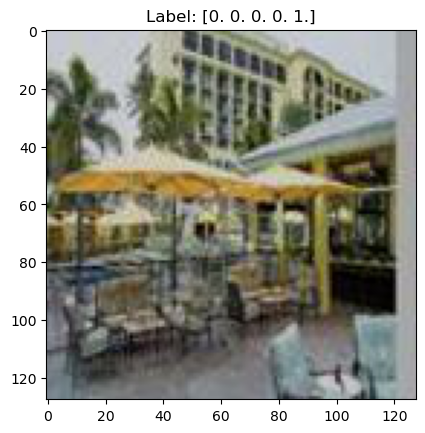

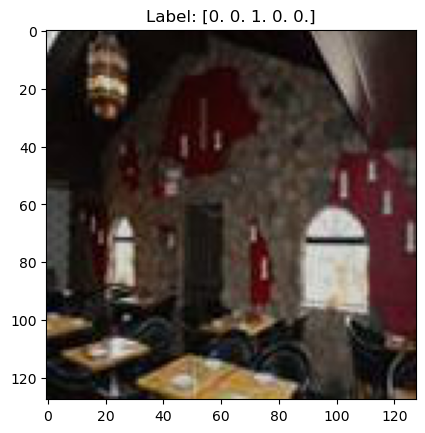

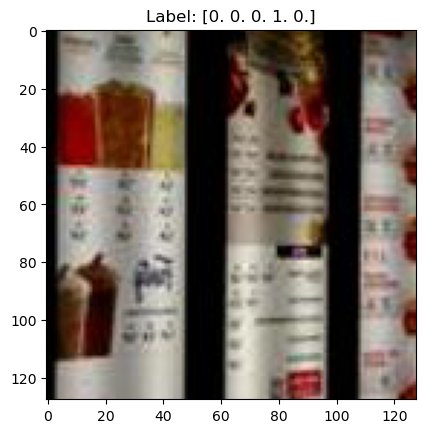

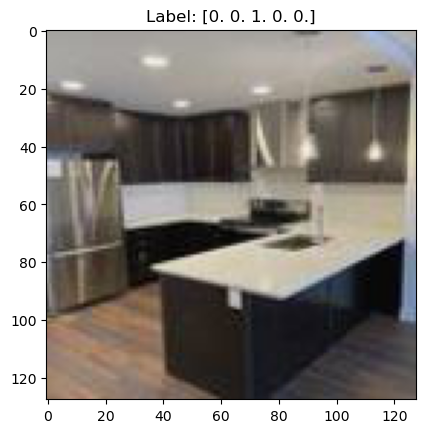

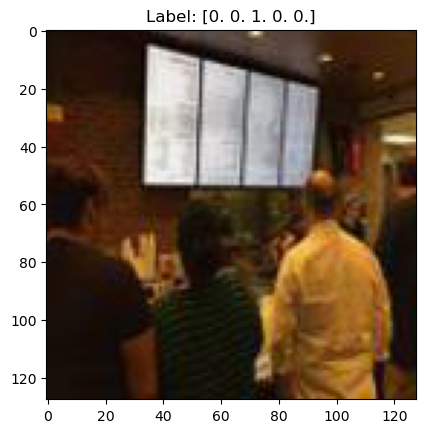

In [15]:
import matplotlib.pyplot as plt

for i in range(5):
    plt.imshow(x_batch[i])
    plt.title(f"Label: {y_batch[i]}")
    plt.show()


**Basic Model 1**

In [16]:
from tensorflow.keras import Input, layers, models

model = models.Sequential([
    Input(shape=(128,128, 3)),        # Input layer for 128x128 RGB images
    layers.Flatten(),                 # Converts image to 1D vector (128*128*3 = 49,152)
    
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.4),
    
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    
    layers.Dense(train_gen.num_classes, activation='softmax')  # Output layer
])
model.compile(optimizer='adam', 
              loss='categorical_crossentropy',
              metrics=['accuracy', tf.keras.metrics.Recall(), tf.keras.metrics.AUC()])


In [17]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=12
)

Epoch 1/12
269/269 ━━━━━━━━━━━━━━━━━━━━ 185s 660ms/step - accuracy: 0.2687 - auc: 0.5795 - loss: 5.4762 - recall: 0.1201 - val_accuracy: 0.3416 - val_auc: 0.6924 - val_loss: 1.4556 - val_recall: 0.0564
Epoch 2/12
269/269 ━━━━━━━━━━━━━━━━━━━━ 79s 295ms/step - accuracy: 0.2461 - auc: 0.5951 - loss: 1.5372 - recall: 0.0107 - val_accuracy: 0.2572 - val_auc: 0.6118 - val_loss: 1.5396 - val_recall: 0.0000e+00
Epoch 3/12
269/269 ━━━━━━━━━━━━━━━━━━━━ 80s 297ms/step - accuracy: 0.2719 - auc: 0.6236 - loss: 1.5124 - recall: 0.0327 - val_accuracy: 0.3569 - val_auc: 0.6983 - val_loss: 1.4434 - val_recall: 0.0960
Epoch 4/12
269/269 ━━━━━━━━━━━━━━━━━━━━ 81s 299ms/step - accuracy: 0.2844 - auc: 0.6366 - loss: 1.5022 - recall: 0.0455 - val_accuracy: 0.3621 - val_auc: 0.7050 - val_loss: 1.4198 - val_recall: 0.1067
Epoch 5/12
269/269 ━━━━━━━━━━━━━━━━━━━━ 80s 296ms/step - accuracy: 0.3031 - auc: 0.6531 - loss: 1.4837 - recall: 0.0559 - val_accuracy: 0.3262 - val_auc: 0.6768 - val_loss: 1.4686 - val_recal

In [18]:
# Evaluate on test set
test_preds = model.predict(X_test)
test_pred_labels = np.argmax(test_preds, axis=1)
test_true_labels = np.argmax(y_test_bin, axis=1)


68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step 


In [19]:
print("\nClassification report:\n", classification_report(test_true_labels, test_pred_labels, target_names=lb.classes_))
print("Confusion Matrix:\n", confusion_matrix(test_true_labels, test_pred_labels))
print("AUC Score:", roc_auc_score(y_test_bin, test_preds, multi_class='ovr'))



Classification report:
               precision    recall  f1-score   support

       drink       0.00      0.00      0.00       507
        food       0.28      0.96      0.43       495
      inside       0.42      0.05      0.09       496
        menu       0.00      0.00      0.00       152
     outside       0.73      0.53      0.61       499

    accuracy                           0.36      2149
   macro avg       0.29      0.31      0.23      2149
weighted avg       0.33      0.36      0.26      2149

Confusion Matrix:
 [[  0 460  11   0  36]
 [  0 476   4   0  15]
 [  0 433  25   0  38]
 [  0 136   6   0  10]
 [  4 218  13   0 264]]
AUC Score: 0.6046188165673806


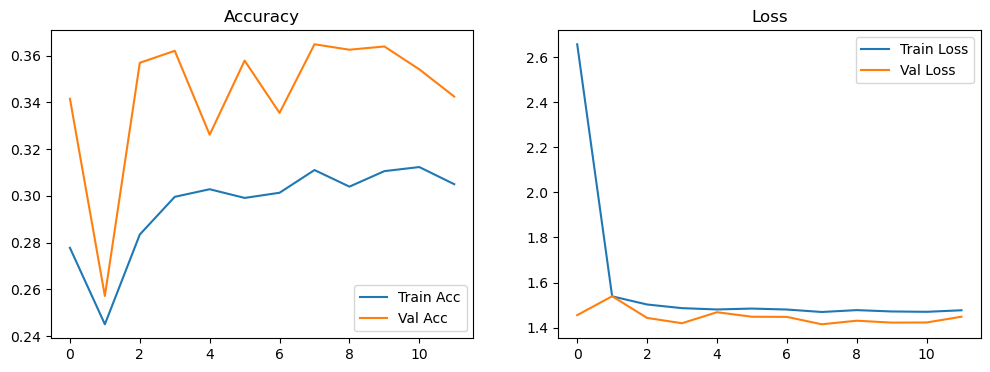

In [20]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title('Accuracy')
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')
plt.show()

In [21]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = (128, 128)
batch_size = 64

train_gen_eval = ImageDataGenerator(rescale=1./255).flow_from_directory(
    'C:\\Users\\Admin\\Downloads\\CV_PROJECT_1\\keras_data\\train',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False  # IMPORTANT for evaluation
)



Found 17192 images belonging to 5 classes.


In [22]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize

# Predict on training set
train_gen_eval.reset()
train_preds = model.predict(train_gen_eval, verbose=1)
train_pred_labels = np.argmax(train_preds, axis=1)
train_true_labels = train_gen_eval.classes

# Get class labels in correct order
class_labels = list(train_gen_eval.class_indices.keys())

# Print metrics
print("=== Train Data Evaluation ===")
print(classification_report(train_true_labels, train_pred_labels, target_names=class_labels))
print("Confusion Matrix (Train):\n", confusion_matrix(train_true_labels, train_pred_labels))
train_true_bin = label_binarize(train_true_labels, classes=range(len(class_labels)))
print("AUC (Train):", roc_auc_score(train_true_bin, train_preds, multi_class='ovr'))


269/269 ━━━━━━━━━━━━━━━━━━━━ 16s 59ms/step
=== Train Data Evaluation ===
              precision    recall  f1-score   support

       drink       0.14      0.00      0.00      3971
        food       0.28      0.97      0.44      4006
      inside       0.33      0.04      0.07      4023
        menu       0.00      0.00      0.00      1191
     outside       0.75      0.54      0.62      4001

    accuracy                           0.36     17192
   macro avg       0.30      0.31      0.23     17192
weighted avg       0.35      0.36      0.26     17192

Confusion Matrix (Train):
 [[   3 3662   74    0  232]
 [   3 3902   31    0   70]
 [   6 3505  164    0  348]
 [   5 1070   41    0   75]
 [   4 1663  187    0 2147]]
AUC (Train): 0.6060485648463403


This architecture is simple and has dropout regularization. 
Performance:

Test accuracy: ~45%

Train accuracy: ~47%

Test AUC: 0.70

Train AUC: 0.72  
Menu has 0 precision and recall, meaning the model never predicted this class correctly.



Model Building 2 - Build a Better DNN (with Dropouts & Multiple Layers & Early stopping)

Added Early stopping to cut off early if validation loss stops improving. Reduce batch_size in ImageDataGenerator to fix the memory error

In [13]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
batch_size = 8  # Reduce from 64 → 8 to save memory

train_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    'C:/Users/Admin/Downloads/CV_PROJECT_1/keras_data/train',
    target_size=(128, 128),
    batch_size=batch_size,
    class_mode='categorical'
)

val_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    'C:/Users/Admin/Downloads/CV_PROJECT_1/keras_data/val',
    target_size=(128, 128),
    batch_size=batch_size,
    class_mode='categorical'
)


Found 17192 images belonging to 5 classes.
Found 2146 images belonging to 5 classes.


In [15]:
from tensorflow.keras import Input, layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

model = models.Sequential([
    Input(shape=(128, 128, 3)),
    layers.Flatten(),
    layers.Dense(1024, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.1),
    layers.Dense(train_gen.num_classes, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=0.0005), 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(train_gen, validation_data=val_gen, epochs=12, callbacks=[early_stop])


Epoch 1/12
2149/2149 ━━━━━━━━━━━━━━━━━━━━ 1137s 527ms/step - accuracy: 0.2247 - loss: 3.8785 - val_accuracy: 0.2335 - val_loss: 1.5468
Epoch 2/12
2149/2149 ━━━━━━━━━━━━━━━━━━━━ 1120s 521ms/step - accuracy: 0.2380 - loss: 1.5425 - val_accuracy: 0.2274 - val_loss: 1.5475
Epoch 3/12
2149/2149 ━━━━━━━━━━━━━━━━━━━━ 1122s 522ms/step - accuracy: 0.2343 - loss: 1.5436 - val_accuracy: 0.2241 - val_loss: 1.5478
Epoch 4/12
2149/2149 ━━━━━━━━━━━━━━━━━━━━ 1120s 521ms/step - accuracy: 0.2363 - loss: 1.5449 - val_accuracy: 0.2265 - val_loss: 1.5473


In [16]:
# Evaluate on test set
test_preds = model.predict(X_test)
test_pred_labels = np.argmax(test_preds, axis=1)
test_true_labels = np.argmax(y_test_bin, axis=1)
print("\nClassification report:\n", classification_report(test_true_labels, test_pred_labels, target_names=lb.classes_))
print("Confusion Matrix:\n", confusion_matrix(test_true_labels, test_pred_labels))
print("AUC Score:", roc_auc_score(y_test_bin, test_preds, multi_class='ovr'))



68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step

Classification report:
               precision    recall  f1-score   support

       drink       0.60      0.01      0.01       507
        food       0.00      0.00      0.00       495
      inside       0.00      0.00      0.00       496
        menu       0.00      0.00      0.00       152
     outside       0.23      1.00      0.38       499

    accuracy                           0.23      2149
   macro avg       0.17      0.20      0.08      2149
weighted avg       0.20      0.23      0.09      2149

Confusion Matrix:
 [[  3   0   0   0 504]
 [  1   0   0   0 494]
 [  1   0   0   0 495]
 [  0   0   0   0 152]
 [  0   0   0   0 499]]
AUC Score: 0.5014864624322847


In [ ]:
Model 2 Interpetations
AUC of 0.5 indicates random guessing—the model isn't learning at all
recision/Recall near 0 for all classes except outside

outside class dominates all predictions → model predicts everything as outside

Model 1 was selected as the final architecture for tuning because it demonstrated better baseline performance, stability, and simplicity compared to model2
Higher Accuracy: Model 1 reached ~45% test accuracy, while Model 2 dropped to ~23%.

Balanced Complexity: It uses three hidden layers with appropriate dropout, avoiding overfitting without excessive depth.



Tuning Step 1: Class Imbalance Handling
Check for class imbalance

Class 'drink': 3971 images
Class 'food': 4006 images
Class 'inside': 4023 images
Class 'menu': 1191 images
Class 'outside': 4001 images


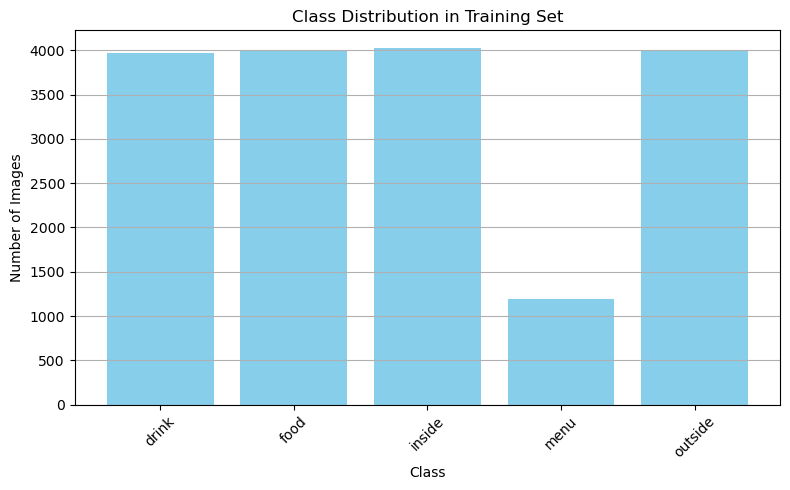

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# Get class labels and counts
labels = train_gen.classes
class_names = list(train_gen.class_indices.keys())

# Count occurrences of each class
unique_classes, counts = np.unique(labels, return_counts=True)

# Print class distribution
for cls, count in zip(unique_classes, counts):
    print(f"Class '{class_names[cls]}': {count} images")

# Optional: Visualize with bar chart
plt.figure(figsize=(8, 5))
plt.bar(class_names, counts, color='skyblue')
plt.title("Class Distribution in Training Set")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


menu has fewer samples compared to the others.

The rest (drink, food, inside, outside) are fairly balanced.

So class imbalance is present, and need to address during training to avoid the model ignoring the minority class (menu).

In [33]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array, array_to_img
import os

src_dir = 'C:/Users/Admin/Downloads/CV_PROJECT_1/keras_data/train/menu'
aug_dir = src_dir  # Save augmented images in the same directory
datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

# Generate 5 augmented images per original
for fname in os.listdir(src_dir):
    if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
        img = load_img(os.path.join(src_dir, fname))
        x = img_to_array(img)
        x = x.reshape((1,) + x.shape)
        prefix = os.path.splitext(fname)[0]
        
        i = 0
        for batch in datagen.flow(x, batch_size=1, save_to_dir=aug_dir, save_prefix=prefix, save_format='jpeg'):
            i += 1
            if i >= 3:
                break

print("Augmented images created for 'menu' class.")


Augmented images created for 'menu' class.


In [34]:
# Verify image count
import os

base_path = 'C:/Users/Admin/Downloads/CV_PROJECT_1/keras_data/train'
for class_name in os.listdir(base_path):
    class_path = os.path.join(base_path, class_name)
    if os.path.isdir(class_path):
        print(f"Class '{class_name}': {len(os.listdir(class_path))} images")


Class 'drink': 3971 images
Class 'food': 4006 images
Class 'inside': 4023 images
Class 'menu': 4764 images
Class 'outside': 4001 images


In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    'C:/Users/Admin/Downloads/CV_PROJECT_1/keras_data/train',
    target_size=(128, 128),
    batch_size=64,
    class_mode='categorical'
)

val_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    'C:/Users/Admin/Downloads/CV_PROJECT_1/keras_data/val',
    target_size=(128, 128),
    batch_size=64,
    class_mode='categorical',
    shuffle=False
)


Found 20765 images belonging to 5 classes.
Found 2146 images belonging to 5 classes.


In [36]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy', tf.keras.metrics.Recall(), tf.keras.metrics.AUC()])


In [37]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(train_gen, validation_data=val_gen, epochs=12, callbacks=[early_stop])

Epoch 1/12
325/325 ━━━━━━━━━━━━━━━━━━━━ 131s 395ms/step - accuracy: 0.2638 - auc_2: 0.5747 - loss: 1.5798 - recall_2: 0.0459 - val_accuracy: 0.1580 - val_auc_2: 0.5408 - val_loss: 1.5493 - val_recall_2: 0.0340
Epoch 2/12
325/325 ━━━━━━━━━━━━━━━━━━━━ 94s 289ms/step - accuracy: 0.2691 - auc_2: 0.5870 - loss: 1.5548 - recall_2: 0.0385 - val_accuracy: 0.2227 - val_auc_2: 0.6187 - val_loss: 1.4930 - val_recall_2: 0.0946
Epoch 3/12
325/325 ━━━━━━━━━━━━━━━━━━━━ 95s 293ms/step - accuracy: 0.2687 - auc_2: 0.5848 - loss: 1.5581 - recall_2: 0.0391 - val_accuracy: 0.1580 - val_auc_2: 0.5351 - val_loss: 1.5771 - val_recall_2: 0.0214
Epoch 4/12
325/325 ━━━━━━━━━━━━━━━━━━━━ 92s 282ms/step - accuracy: 0.2800 - auc_2: 0.5963 - loss: 1.5455 - recall_2: 0.0446 - val_accuracy: 0.1976 - val_auc_2: 0.5771 - val_loss: 1.5533 - val_recall_2: 0.0042
Epoch 5/12
325/325 ━━━━━━━━━━━━━━━━━━━━ 91s 280ms/step - accuracy: 0.2776 - auc_2: 0.5939 - loss: 1.5498 - recall_2: 0.0418 - val_accuracy: 0.1542 - val_auc_2: 0.5

In [38]:
# Evaluate on test set
test_preds = model.predict(X_test)
test_pred_labels = np.argmax(test_preds, axis=1)
test_true_labels = np.argmax(y_test_bin, axis=1)
print("\nClassification report:\n", classification_report(test_true_labels, test_pred_labels, target_names=lb.classes_))
print("Confusion Matrix:\n", confusion_matrix(test_true_labels, test_pred_labels))
print("AUC Score:", roc_auc_score(y_test_bin, test_preds, multi_class='ovr'))


68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step

Classification report:
               precision    recall  f1-score   support

       drink       0.00      0.00      0.00       507
        food       0.00      0.00      0.00       495
      inside       0.38      0.03      0.06       496
        menu       0.08      0.72      0.14       152
     outside       0.49      0.70      0.58       499

    accuracy                           0.22      2149
   macro avg       0.19      0.29      0.16      2149
weighted avg       0.21      0.22      0.16      2149

Confusion Matrix:
 [[  0   0   3 390 114]
 [  0   0  11 405  79]
 [  0   0  17 349 130]
 [  0   0   4 110  38]
 [  0   0  10 140 349]]
AUC Score: 0.6290599733090347


In [39]:
# Step 1: Get true labels
y_train_true = train_gen.classes  # integer labels
class_names = list(train_gen.class_indices.keys())

# Step 2: Predict on train data (no shuffle)
train_gen.reset()  # reset the generator
train_preds = model.predict(train_gen)
y_train_pred = np.argmax(train_preds, axis=1)

# Step 3: One-hot true labels for AUC
from sklearn.preprocessing import label_binarize
y_train_bin = label_binarize(y_train_true, classes=np.arange(train_gen.num_classes))

# Step 4: Print evaluation results
print("\n=== Train Data Evaluation ===")
print("Classification report:\n", classification_report(y_train_true, y_train_pred, target_names=class_names))
print("Confusion Matrix:\n", confusion_matrix(y_train_true, y_train_pred))
print("AUC (Train):", roc_auc_score(y_train_bin, train_preds, multi_class='ovr'))


325/325 ━━━━━━━━━━━━━━━━━━━━ 35s 108ms/step

=== Train Data Evaluation ===
Classification report:
               precision    recall  f1-score   support

       drink       0.00      0.00      0.00      3971
        food       0.00      0.00      0.00      4006
      inside       0.21      0.02      0.03      4023
        menu       0.23      0.66      0.34      4764
     outside       0.19      0.32      0.24      4001

    accuracy                           0.22     20765
   macro avg       0.13      0.20      0.12     20765
weighted avg       0.13      0.22      0.13     20765

Confusion Matrix:
 [[   0    0   70 2638 1263]
 [   0    0   58 2679 1269]
 [   0    0   71 2682 1270]
 [   0    0   79 3152 1533]
 [   0    0   64 2659 1278]]
AUC (Train): 0.50046365701181


Accuracy (Train & Test):
Train Accuracy: 22%

Test Accuracy: 22%

These are very low and almost equal, suggesting the model is not learning well from the data — not even on training.
AUC Score:
Train AUC: 0.50 (no better than random guessing)

Test AUC: 0.63 (slightly better, but still weak)
model is likely underfitting:

It fails to learn class boundaries even with 20K+ training samples.

The same poor accuracy on both training and test means the model is not even fitting the training data well.

Even after addressing class imbalance, performance didn’t improve — indicating deeper architectural or optimization issues.


Tuning 2 — Add Batch Normalization
We now modify your DNN to include BatchNormalization after each Dense and before Dropout.

In [40]:
from tensorflow.keras import models, layers, Input
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

# Build model
model = models.Sequential([
    Input(shape=(128, 128, 3)),
    layers.Flatten(),

    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),

    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(train_gen.num_classes, activation='softmax')
])

# Compile
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(), tf.keras.metrics.AUC()]
)

# Add EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True,
    verbose=1
)

# Train
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=12,
    callbacks=[early_stop]
)


Epoch 1/12
325/325 ━━━━━━━━━━━━━━━━━━━━ 102s 301ms/step - accuracy: 0.3891 - auc_3: 0.6965 - loss: 1.6044 - recall_3: 0.2400 - val_accuracy: 0.5014 - val_auc_3: 0.7920 - val_loss: 1.2483 - val_recall_3: 0.2596
Epoch 2/12
325/325 ━━━━━━━━━━━━━━━━━━━━ 98s 303ms/step - accuracy: 0.4690 - auc_3: 0.7716 - loss: 1.3163 - recall_3: 0.2751 - val_accuracy: 0.5158 - val_auc_3: 0.8112 - val_loss: 1.2001 - val_recall_3: 0.2307
Epoch 3/12
325/325 ━━━━━━━━━━━━━━━━━━━━ 97s 299ms/step - accuracy: 0.4931 - auc_3: 0.7946 - loss: 1.2460 - recall_3: 0.2951 - val_accuracy: 0.4981 - val_auc_3: 0.7996 - val_loss: 1.2294 - val_recall_3: 0.2311
Epoch 4/12
325/325 ━━━━━━━━━━━━━━━━━━━━ 97s 300ms/step - accuracy: 0.5117 - auc_3: 0.8061 - loss: 1.2120 - recall_3: 0.3022 - val_accuracy: 0.4595 - val_auc_3: 0.7783 - val_loss: 1.2836 - val_recall_3: 0.2740
Epoch 5/12
325/325 ━━━━━━━━━━━━━━━━━━━━ 96s 295ms/step - accuracy: 0.5241 - auc_3: 0.8151 - loss: 1.1871 - recall_3: 0.3190 - val_accuracy: 0.5294 - val_auc_3: 0.8

In [41]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# True labels from test_gen
y_test_true = test_gen.classes
class_names = list(test_gen.class_indices.keys())

# Predict on test set
test_gen.reset()
test_preds = model.predict(test_gen)
y_test_pred = np.argmax(test_preds, axis=1)

# One-hot true labels for AUC
from sklearn.preprocessing import label_binarize
y_test_bin = label_binarize(y_test_true, classes=np.arange(len(class_names)))

# Print report
print("\n=== Test Data Evaluation ===")
print("Classification Report:\n", classification_report(y_test_true, y_test_pred, target_names=class_names))
print("Confusion Matrix:\n", confusion_matrix(y_test_true, y_test_pred))
print("AUC Score:", roc_auc_score(y_test_bin, test_preds, multi_class='ovr'))


34/34 ━━━━━━━━━━━━━━━━━━━━ 16s 465ms/step

=== Test Data Evaluation ===
Classification Report:
               precision    recall  f1-score   support

       drink       0.54      0.27      0.36       507
        food       0.58      0.57      0.58       495
      inside       0.46      0.74      0.57       496
        menu       0.30      0.62      0.41       152
     outside       0.81      0.50      0.62       499

    accuracy                           0.53      2149
   macro avg       0.54      0.54      0.51      2149
weighted avg       0.58      0.53      0.52      2149

Confusion Matrix:
 [[137 113 170  58  29]
 [ 75 283  76  48  13]
 [ 18  45 366  56  11]
 [  7  19  27  94   5]
 [ 17  26 150  55 251]]
AUC Score: 0.8148336528446762


In [42]:
# Get true labels
y_train_true = train_gen_eval.classes

# Predict on training data
train_gen_eval.reset()
train_preds = model.predict(train_gen_eval)
y_train_pred = np.argmax(train_preds, axis=1)

# One-hot labels for AUC
y_train_bin = label_binarize(y_train_true, classes=np.arange(len(class_names)))

# Print results
print("\n=== Train Data Evaluation ===")
print("Classification Report:\n", classification_report(y_train_true, y_train_pred, target_names=class_names))
print("Confusion Matrix:\n", confusion_matrix(y_train_true, y_train_pred))
print("AUC Score:", roc_auc_score(y_train_bin, train_preds, multi_class='ovr'))


269/269 ━━━━━━━━━━━━━━━━━━━━ 16s 58ms/step

=== Train Data Evaluation ===
Classification Report:
               precision    recall  f1-score   support

       drink       0.56      0.26      0.35      3971
        food       0.63      0.60      0.61      4006
      inside       0.47      0.74      0.57      4023
        menu       0.27      0.63      0.37      1191
     outside       0.84      0.49      0.62      4001

    accuracy                           0.53     17192
   macro avg       0.55      0.54      0.51     17192
weighted avg       0.60      0.53      0.53     17192

Confusion Matrix:
 [[1020  879 1370  541  161]
 [ 469 2404  692  367   74]
 [ 135  252 2997  538  101]
 [  37  113  268  751   22]
 [ 158  167 1102  623 1951]]
AUC Score: 0.8291016942927859


1. Accuracy Improved to 53%
Before batch normalization: Accuracy was around 22–36%.

After batch normalization: Jumped to 53% on both train and test.

This suggests the model generalizes better and is learning more stable features across layers.
drink	27%	Much better than 0% earlier but still needs attention.
food	57%	Balanced and strong.
inside	74%	Excellent recall — model is confident here.
menu	62%	Previously a minority class, now recall is high. Your class balancing worked.
outside	50%	Solid and improved — also high precision (81%).
Test AUC: 0.81

Train AUC: 0.83
This means the model has good separation ability 


Tuning 3 - Cross validation

In [1]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array

def load_images_and_labels(base_dir, img_size=(128, 128)):
    class_names = sorted(os.listdir(base_dir))
    X = []
    y = []

    for label_index, class_name in enumerate(class_names):
        class_path = os.path.join(base_dir, class_name)
        if not os.path.isdir(class_path):
            continue
        for file_name in os.listdir(class_path):
            if file_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                img_path = os.path.join(class_path, file_name)
                try:
                    img = load_img(img_path, target_size=img_size)
                    img_array = img_to_array(img)
                    X.append(img_array)
                    y.append(label_index)
                except Exception as e:
                    print(f"Error loading {img_path}: {e}")

    X = np.array(X, dtype='float32') / 255.0
    y = np.array(y)
    return X, y, class_names


In [2]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import models, layers, Input
import tensorflow as tf

# Load dataset for training and testing
X, y, class_names = load_images_and_labels('C:/Users/Admin/Downloads/CV_PROJECT_1/keras_data/train', (128, 128))
X_test, y_test, _ = load_images_and_labels('C:/Users/Admin/Downloads/CV_PROJECT_1/keras_data/test', (128, 128))
y_test_cat = to_categorical(y_test)

# Sample 30% for k-fold training to save memory
sample_size = int(0.3 * len(X))
indices = np.random.choice(len(X), size=sample_size, replace=False)
X = X[indices]
y = y[indices]

# Stratified K-Fold Cross Validation
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_accuracies = []
best_model = None
best_accuracy = 0.0

for fold, (train_idx, val_idx) in enumerate(kfold.split(X, y)):
    print(f"\n--- Fold {fold+1} ---")
    X_train, X_val = X[train_idx], X[val_idx]
    y_train = to_categorical(y[train_idx])
    y_val = to_categorical(y[val_idx])

    model = models.Sequential([
        Input(shape=(128, 128, 3)),
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.4),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        layers.Dense(len(class_names), activation='softmax')
    ])

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

    model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=15,
        callbacks=[early_stop],
        verbose=1
    )

    _, acc = model.evaluate(X_val, y_val, verbose=0)
    print(f"Validation Accuracy for Fold {fold+1}: {acc:.4f}")
    fold_accuracies.append(acc)

    if acc > best_accuracy:
        best_accuracy = acc
        best_model = tf.keras.models.clone_model(model)
        best_model.set_weights(model.get_weights())

print(f"\nAverage Accuracy across folds: {np.mean(fold_accuracies):.4f}")
print(f"Best Validation Accuracy: {best_accuracy:.4f}")


# Save the best model
best_model.save("best_dnn_model.h5")
print("✅ Best model saved as 'best_dnn_model.h5'")



--- Fold 1 ---
Epoch 1/15
156/156 ━━━━━━━━━━━━━━━━━━━━ 48s 273ms/step - accuracy: 0.3126 - loss: 1.8264 - val_accuracy: 0.3652 - val_loss: 1.6770
Epoch 2/15
156/156 ━━━━━━━━━━━━━━━━━━━━ 43s 274ms/step - accuracy: 0.4187 - loss: 1.4272 - val_accuracy: 0.4470 - val_loss: 1.3501
Epoch 3/15
156/156 ━━━━━━━━━━━━━━━━━━━━ 42s 267ms/step - accuracy: 0.4389 - loss: 1.3719 - val_accuracy: 0.4278 - val_loss: 1.4155
Epoch 4/15
156/156 ━━━━━━━━━━━━━━━━━━━━ 42s 268ms/step - accuracy: 0.4849 - loss: 1.2794 - val_accuracy: 0.4502 - val_loss: 1.3574
Epoch 5/15
156/156 ━━━━━━━━━━━━━━━━━━━━ 42s 271ms/step - accuracy: 0.4852 - loss: 1.2566 - val_accuracy: 0.4294 - val_loss: 1.3748
Validation Accuracy for Fold 1: 0.4470

--- Fold 2 ---
Epoch 1/15
156/156 ━━━━━━━━━━━━━━━━━━━━ 47s 267ms/step - accuracy: 0.3345 - loss: 1.8590 - val_accuracy: 0.3419 - val_loss: 1.6726
Epoch 2/15
156/156 ━━━━━━━━━━━━━━━━━━━━ 41s 264ms/step - accuracy: 0.4135 - loss: 1.4736 - val_accuracy: 0.4567 - val_loss: 1.2931
Epoch 3/15
1

Validation Accuracy for Fold 5: 0.4803

Average Accuracy across folds: 0.4792
Best Validation Accuracy: 0.5136
✅ Best model saved as 'best_dnn_model.h5'


In [3]:
# Evaluate best model on test set
test_preds = best_model.predict(X_test)
test_pred_labels = np.argmax(test_preds, axis=1)
test_true_labels = y_test  # not one-hot
print("\n=== Test Set Evaluation ===")
print("Classification Report:\n", classification_report(test_true_labels, test_pred_labels, target_names=class_names))
print("Confusion Matrix:\n", confusion_matrix(test_true_labels, test_pred_labels))
print("AUC Score:", roc_auc_score(y_test_cat, test_preds, multi_class='ovr'))


68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step  

=== Test Set Evaluation ===
Classification Report:
               precision    recall  f1-score   support

       drink       0.45      0.15      0.23       507
        food       0.54      0.62      0.58       495
      inside       0.53      0.65      0.58       496
        menu       0.23      0.57      0.33       152
     outside       0.70      0.59      0.64       499

    accuracy                           0.51      2149
   macro avg       0.49      0.52      0.47      2149
weighted avg       0.53      0.51      0.49      2149

Confusion Matrix:
 [[ 77 157 109 114  50]
 [ 38 309  42  83  23]
 [ 35  52 323  45  41]
 [  2  21  28  86  15]
 [ 20  37 110  38 294]]
AUC Score: 0.7875578505795389


In [6]:
for fold, (train_idx, val_idx) in enumerate(kfold.split(X, y)):
    print(f"\n--- Fold {fold+1} ---")

    X_train, X_val = X[train_idx], X[val_idx]
    y_train_raw, y_val_raw = y[train_idx], y[val_idx]  # <-- SAVE raw labels before one-hot
    y_train = to_categorical(y_train_raw)
    y_val = to_categorical(y_val_raw)


# Predict on train set
train_preds = best_model.predict(X_train)
train_pred_labels = np.argmax(train_preds, axis=1)
train_true_labels = y_train_raw  # original integer labels before one-hot encoding

print("\n=== Train Set Evaluation ===")
print("Classification Report:\n", classification_report(train_true_labels, train_pred_labels, target_names=class_names))
print("Confusion Matrix:\n", confusion_matrix(train_true_labels, train_pred_labels))
print("AUC Score:", roc_auc_score(y_train, train_preds, multi_class='ovr'))



--- Fold 1 ---

--- Fold 2 ---

--- Fold 3 ---

--- Fold 4 ---

--- Fold 5 ---
156/156 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step

=== Train Set Evaluation ===
Classification Report:
               precision    recall  f1-score   support

       drink       0.45      0.17      0.25       984
        food       0.53      0.63      0.57       984
      inside       0.45      0.68      0.54       960
        menu       0.57      0.58      0.58      1115
     outside       0.67      0.60      0.63       941

    accuracy                           0.53      4984
   macro avg       0.53      0.53      0.51      4984
weighted avg       0.53      0.53      0.51      4984

Confusion Matrix:
 [[169 332 243 153  87]
 [ 72 618  93 161  40]
 [ 54  77 651  89  89]
 [ 40  96 272 649  58]
 [ 42  53 200  82 564]]
AUC Score: 0.8154403661121954


In [2]:
import numpy as np
from tensorflow.keras.models import load_model, clone_model
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

# Load full dataset (update the path if needed)
X_full, y_full, class_names = load_images_and_labels('C:/Users/Admin/Downloads/CV_PROJECT_1/keras_data/train', (128, 128))
y_full_cat = to_categorical(y_full)

# Load the best model (with weights from cross-validation)
original_model = load_model("best_dnn_model.h5")

# Clone the architecture (weights will be randomly initialized)
model = clone_model(original_model)
model.build((None, 128, 128, 3))  # Define the input shape explicitly

# Compile again
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# Train on full dataset
history = model.fit(
    X_full, y_full_cat,
    epochs=12,
    batch_size=64,
    validation_split=0.1,  # Optional: keep 10% for validation
    verbose=1
)

# Save the final model trained on full data
model.save("final_dnn_model_full_data.h5")
print("✅ Final model saved as 'final_dnn_model_full_data.h5'")


Epoch 1/12
292/292 ━━━━━━━━━━━━━━━━━━━━ 102s 312ms/step - accuracy: 0.3605 - loss: 1.6783 - val_accuracy: 0.3914 - val_loss: 1.6409
Epoch 2/12
292/292 ━━━━━━━━━━━━━━━━━━━━ 88s 301ms/step - accuracy: 0.4621 - loss: 1.3061 - val_accuracy: 0.3823 - val_loss: 1.4413
Epoch 3/12
292/292 ━━━━━━━━━━━━━━━━━━━━ 89s 306ms/step - accuracy: 0.4891 - loss: 1.2467 - val_accuracy: 0.5243 - val_loss: 1.2852
Epoch 4/12
292/292 ━━━━━━━━━━━━━━━━━━━━ 87s 299ms/step - accuracy: 0.4936 - loss: 1.2356 - val_accuracy: 0.6654 - val_loss: 0.9634
Epoch 5/12
292/292 ━━━━━━━━━━━━━━━━━━━━ 83s 286ms/step - accuracy: 0.5083 - loss: 1.2190 - val_accuracy: 0.5542 - val_loss: 1.2496
Epoch 6/12
292/292 ━━━━━━━━━━━━━━━━━━━━ 83s 283ms/step - accuracy: 0.5122 - loss: 1.1887 - val_accuracy: 0.4656 - val_loss: 1.3311
Epoch 7/12
292/292 ━━━━━━━━━━━━━━━━━━━━ 83s 283ms/step - accuracy: 0.5046 - loss: 1.2003 - val_accuracy: 0.4791 - val_loss: 1.3138
Epoch 8/12
292/292 ━━━━━━━━━━━━━━━━━━━━ 85s 291ms/step - accuracy: 0.5242 - loss: 

✅ Final model saved as 'final_dnn_model_full_data.h5'


In [3]:
pip install lime shap



   ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
   -- ------------------------------------- 0.7/12.8 MB 20.5 MB/s eta 0:00:01
   ------ --------------------------------- 2.0/12.8 MB 21.2 MB/s eta 0:00:01
   ----------- ---------------------------- 3.6/12.8 MB 25.3 MB/s eta 0:00:01
   ----------------- ---------------------- 5.6/12.8 MB 29.5 MB/s eta 0:00:01
   ----------------------- ---------------- 7.6/12.8 MB 32.2 MB/s eta 0:00:01
   ------------------------------ --------- 9.7/12.8 MB 34.4 MB/s eta 0:00:01
   ----------------------------------- ---- 11.4/12.8 MB 38.6 MB/s eta 0:00:01
   ---------------------------------------  12.8/12.8 MB 38.6 MB/s eta 0:00:01
   ---------------------------------------  12.8/12.8 MB 38.6 MB/s eta 0:00:01
   ---------------------------------------- 12.8/12.8 MB 28.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ------------------ --------------------- 1.3/2.8 MB 40.0 MB/s eta 0:00:01

C:\Users\Admin\anaconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\Admin\anaconda3\Lib\site-packages\shap\explainers\_deep\deep_tf.py:99: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn("Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.")
C:\Users\Admin\anaconda3\Lib\site-packages\keras\src\models\functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: input_layer_3. Received: the structure of inputs=['*']
  warnings.warn(


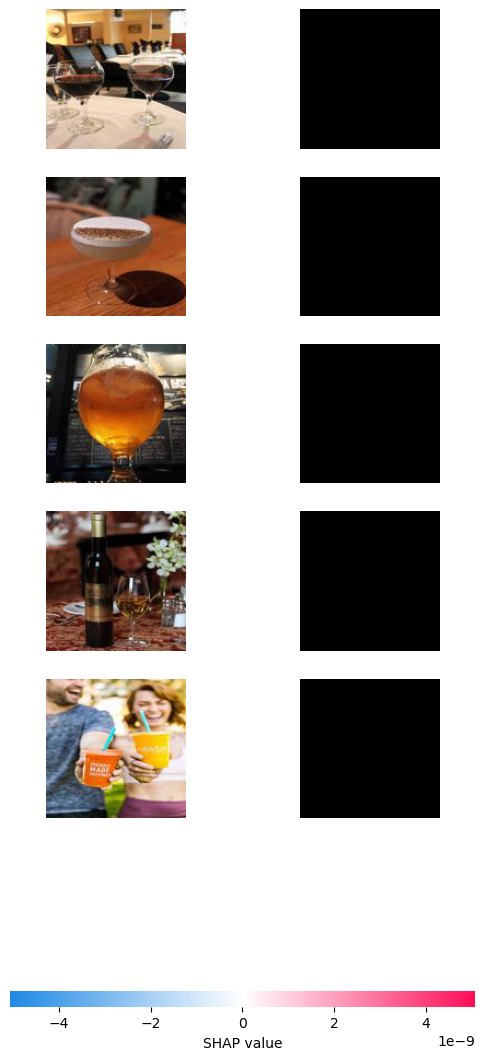

In [4]:
import shap
X_train, y_train, class_names = load_images_and_labels('C:/Users/Admin/Downloads/CV_PROJECT_1/keras_data/train', (128, 128))
X_test, y_test, _ = load_images_and_labels('C:/Users/Admin/Downloads/CV_PROJECT_1/keras_data/test', (128, 128))
# SHAP expects a background dataset – select a small subset of training images
background = X_train[np.random.choice(X_train.shape[0], 100, replace=False)]

# DeepExplainer for DNN
explainer = shap.DeepExplainer(model, background)

# Select a few test images to explain
test_sample = X_test[:5]

# Compute SHAP values
shap_values = explainer.shap_values(test_sample)

# Plot SHAP for each class (you can choose one)
shap.image_plot(shap_values, test_sample)


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step


  1%|          | 10/1000 [00:00<00:54, 18.12it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


  2%|▏         | 20/1000 [00:00<00:29, 33.74it/s]

...

 96%|█████████▌| 960/1000 [00:08<00:00, 133.52it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


 98%|█████████▊| 980/1000 [00:08<00:00, 133.34it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


100%|██████████| 1000/1000 [00:08<00:00, 114.86it/s]


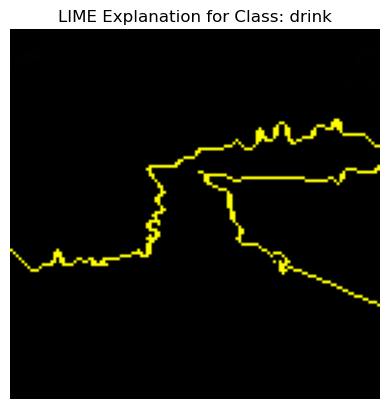

In [5]:
from lime import lime_image
from skimage.segmentation import mark_boundaries
import matplotlib.pyplot as plt
import numpy as np

# Instantiate LIME image explainer
explainer = lime_image.LimeImageExplainer()

# Select one image from test set
i = 0
image = X_test[i]  # shape: (128, 128, 3)
image_reshaped = np.expand_dims(image, axis=0)

# Explain the prediction
explanation = explainer.explain_instance(
    image.astype('double'), 
    classifier_fn=model.predict, 
    top_labels=1,
    hide_color=0,
    num_samples=1000  # more = better explanation
)

# Show explanation
temp, mask = explanation.get_image_and_mask(
    explanation.top_labels[0], positive_only=True, num_features=5, hide_rest=False
)

plt.imshow(mark_boundaries(temp / 255.0, mask))
plt.title(f"LIME Explanation for Class: {class_names[explanation.top_labels[0]]}")
plt.axis('off')
plt.show()


In [ ]:
LIME Explanation for Class: drink

The image shown under "LIME Explanation" is a segmentation mask where LIME has highlighted superpixels (groups of pixels) that most influenced the model's prediction for the class "drink".

The yellow outlines indicate important regions in the image that the model relied on while classifying it as drink

Summary
Balanced the “menu” class using augmentation.

Used BatchNormalization after each Dense layer.

Applied early stopping to prevent overfitting.

Evaluated using Stratified K-Fold CV — better generalization.

Interpretation quality may be limited for a DNN (Flatten-based). A CNN would retain more spatial detail, improving LIME's fidelity.